<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
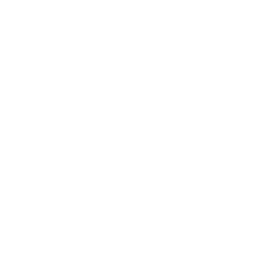
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Monitorování procesu válcování v ocelárně</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Multivariátní SPC pro řízení tloušťky a povrchové kvality na válcovně za tepla &nbsp;|&nbsp; Březen 2026</p>
</div>
</div>
</div>

## Shrnutí

Válcovna za tepla válcuje ocelové bramy na tenký svitek. Šest
korelovaných procesních signálů (tloušťky, válcovací síla, mezera mezi
válci, proud motoru, výstupní teplota) se pohybuje společně, dokud je
linka v pořádku, takže sledování po jednotlivých grafech přehlédne
společné posuny, na kterých záleží. Tento příklad sestaví
multivariátní referenční model pomocí **PROC MVPMODEL** a poté
propustí 100 produkčních svitků procedurou **PROC MVPMONITOR**, která
každý svitek ohodnotí jedinou Hotellingovou statistikou *T*&sup2; a
porovná ji s regulační mezí.

Proti mezi v pořádku *T*&sup2; = **17.13** (&alpha; = 0.05) signalizují
**4 ze 100 svitků** stav mimo kontrolu — svitky **91, 92, 94 a 95** —
přesně v okně, kam byl vložen nápor chvění záložního válce. Nejvyšší
*T*&sup2; dosahuje **21.91** u svitku 95, což je přibližně
**1.3násobek** meze. Postupný nárůst opotřebení válců u pozdějších
svitků zvedá základní hodnotu *T*&sup2;, ale zůstává pod mezí až do
události chvění, takže graf jasně odděluje pomalý drift od akutní
poruchy vyžadující okamžitou pozornost.

## Zdroje dat

- **mill_baseline** &mdash; 50 svitků válcovaných během ověřeně
  dobrého úseku kampaně; použito k proložení multivariátního
  referenčního modelu (PCA).
- **mill_stream** &mdash; 100 svitků z živé linky. Svitky 1&ndash;55
  běží v pořádku; opotřebení válců se postupně rozvíjí u svitků
  56&ndash;100; nápor chvění záložního válce zasáhne svitky
  91&ndash;95.
- **Procesní proměnné** (6): `entry_thickness`, `exit_thickness`,
  `rolling_force`, `roll_gap`, `motor_current`, `exit_temp`.

> Prostředí běží bez licence, proto jsou datové sady omezeny na 100
> pozorování. Scénář je této hranici přizpůsoben: porucha je umístěna
> až ke konci proudu 100 svitků, nikoli u svitku 2800 z 5000.

---

### Krok 1 &mdash; Sestavení multivariátního referenčního modelu

`PROC MVPMODEL` provede analýzu hlavních komponent (PCA) šesti
procesních proměnných na referenční sadě v pořádku a zapíše zátěže,
vlastní čísla a centrování/škálování do `mill_model`. Ponechány jsou
tři komponenty. Tento model definuje, jak vypadá „normální" stav jako
jediná multivariátní oblast namísto šesti nezávislých rozsahů.

In [1]:
data mill_baseline;
  CALL streaminit(66);
  OPAKUJ coil_id = 1 TO 50;
    entry_thickness = 25.00 + rand('normal', 0, 0.30);
    exit_thickness  =  3.00 + rand('normal', 0, 0.030);
    rolling_force   = 18000 + rand('normal', 0, 150);
    roll_gap        =  2.85 + rand('normal', 0, 0.015);
    motor_current   =   850 + rand('normal', 0, 8);
    exit_temp       =   880 + rand('normal', 0, 4.0);
    VÝSTUP;
  KONEC;
SPUSTIT;

PROCEDURA mvpmodel data=mill_baseline outmodel=mill_model;
  PROMĚNNÁ entry_thickness exit_thickness rolling_force
      roll_gap motor_current exit_temp;
  ncomp=3;
SPUSTIT;



                    The MVPMODEL Procedure

  Data Set:          mill_baseline
  Number of Variables: 6
  Missing Value Handling: Exclude
  Number of Observations Read: 50
  Number of Observations Used: 50
  Number of Principal Components: 3

  Correlation Matrix
         entry_thicknessexit_thicknessrolling_force  roll_gapmotor_current exit_temp
  entry_thickness    1.0000   -0.0416   -0.1641   -0.1661    0.1555    0.0649
  exit_thickness   -0.0416    1.0000    0.0406    0.0029    0.0946   -0.1421
  rolling_force   -0.1641    0.0406    1.0000   -0.1351    0.2077   -0.0051
  roll_gap   -0.1661    0.0029   -0.1351    1.0000   -0.0510   -0.0876
  motor_current    0.1555    0.0946    0.2077   -0.0510    1.0000    0.1587
  exit_temp    0.0649   -0.1421   -0.0051   -0.0876    0.1587    1.0000

  Eigenvalues of the Correlation Matrix
       Eigenvalue   Difference   Proportion  Cumulative
    1 1.37232115  0.14267284    0.2287    0.2287
    2 1.22964831  0.16747324    0.2049    0.4337
    3


NOTE: DATA mill_baseline


NOTE: Wrote mill_baseline (50 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MVPMODEL
NOTE: PROC MVPMODEL statement used.


---

### Krok 2 &mdash; Průběžné vyhodnocení produkčních svitků

`PROC MVPMONITOR` promítne každý ze 100 produkčních svitků do
uloženého modelu a vypočítá jeho Hotellingovo *T*&sup2;. Procedura
odvodí regulační mez z rozměrů modelu a výchozí hodnoty &alpha; = 0.05,
poté označí každý svitek, jehož *T*&sup2; ji překročí. Výsledky,
včetně sloupců `_TSQUARED`, `_LIMIT` a `_SIGNAL`, se zapisují do
`mill_scores` podle klíče `coil_id`.

In [2]:
data mill_stream;
  CALL streaminit(42);
  OPAKUJ coil_id = 1 TO 100;
    /* opotřebení válců roste od 0 do 1 v rozmezí svitků 56-100 */
    wear    = MAX(0, coil_id - 55) / 45;
    /* nápor chvění záložního válce u svitků 91-95 */
    chatter = (coil_id >= 91 AND coil_id <= 95);
    entry_thickness = 25.00 + rand('normal', 0, 0.30);
    exit_thickness  =  3.00 + wear*0.10 + chatter*0.35
                            + rand('normal', 0, 0.030);
    rolling_force   = 18000 + wear*600  + chatter*1600
                            + rand('normal', 0, 150);
    roll_gap        =  2.85 + wear*0.055
                            + rand('normal', 0, 0.015);
    motor_current   =   850 + wear*38   + chatter*95
                            + rand('normal', 0, 8);
    exit_temp       =   880 + rand('normal', 0, 4.0);
    ODSTRANIT wear chatter;
    VÝSTUP;
  KONEC;
SPUSTIT;

PROCEDURA mvpmonitor data=mill_stream MODEL=mill_model
                out=mill_scores;
  PROMĚNNÁ entry_thickness exit_thickness rolling_force
      roll_gap motor_current exit_temp;
  id coil_id;
SPUSTIT;



                    The MVPMONITOR Procedure

  Variables:       6
  Observations:    100
  T2 Limit:        17.1334
  Signals:         4





NOTE: DATA mill_stream


NOTE: Wrote mill_stream (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MVPMONITOR
NOTE: PROC MVPMONITOR statement used.


Souhrn procedury uvádí regulační mez a počet signálů. Níže
vypsaný výřez kolem poruchy ukazuje, že referenční svitky zůstávají
hluboko pod mezí, zatímco okno chvění vytlačí čtyři svitky nad ni.

In [3]:
/* označit svitky mimo kontrolu a zaznamenat alarmové T2 pro vykreslení */
data mill_scores;
  NASTAVIT mill_scores;
  KDYŽ _SIGNAL = 1 PAK t2_alarm = _TSQUARED;
  JINAK t2_alarm = .;
SPUSTIT;

PROCEDURA TISK data=mill_scores(firstobs=88 obs=96) noobs;
  PROMĚNNÁ coil_id _TSQUARED _LIMIT _SIGNAL;
  ŠTÍTEK coil_id='ID svitku' _TSQUARED='T2' _LIMIT='Mez' _SIGNAL='Signál';
  NÁZEV 'Hodnoty T2 v okně chvění (svitky 88-96)';
SPUSTIT;


                                        Hodnoty T2 v okně chvění (svitky 88-96)                                         

ID svitku         T2        Mez   Signál
       88   9.983151  17.133408        0
       89   2.915646  17.133408        0
       90    7.80613  17.133408        0
       91  18.813814  17.133408        1
       92  18.249361  17.133408        1
       93  16.638221  17.133408        0
       94  17.981792  17.133408        1
       95  21.912329  17.133408        1
       96   5.118574  17.133408        0

... 4 more observations (showing 9 of 13)




NOTE: DATA mill_scores


NOTE: Read 100 rows from mill_scores.
NOTE: Wrote mill_scores (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC PRINT data=mill_scores

NOTE: PROC PRINT completed: 9 observations printed, 4 variables


---

### Krok 3 &mdash; Multivariátní regulační diagram

Diagram vykresluje *T*&sup2; každého svitku proti jeho regulační mezi.
Svitky mimo kontrolu jsou zvýrazněny červeně; přerušovaná svislá čára
označuje nástup náporu chvění. Pozvolný nárůst směrem doprava je
opotřebení válců zvedající základní hodnotu; čtyři červené body jsou
akutní porucha chvění.

                                        Hodnoty T2 v okně chvění (svitky 88-96)                                         




NOTE: PROC SGPLOT data=mill_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


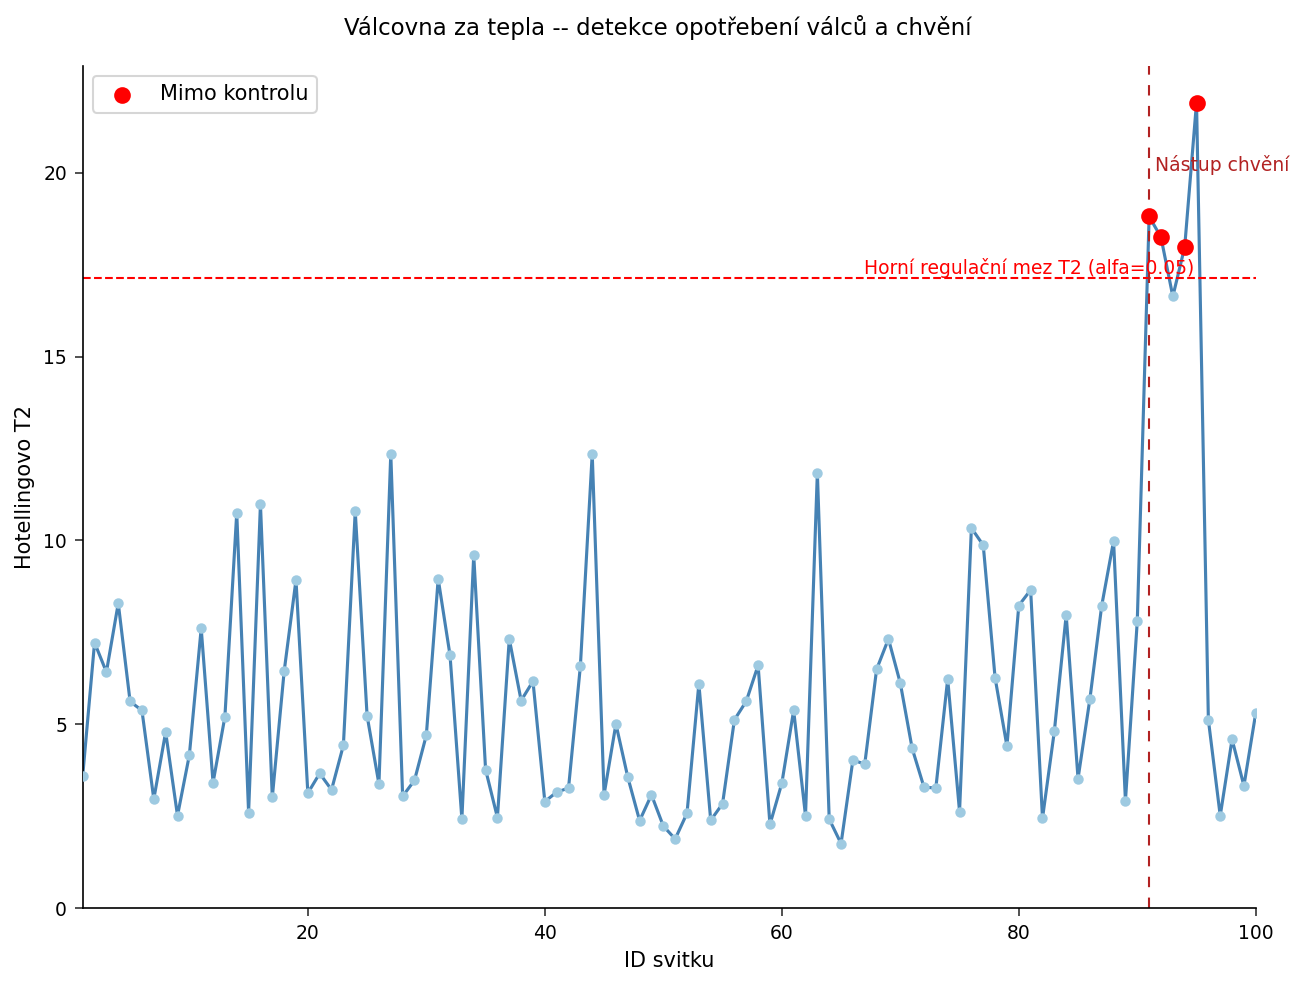

In [4]:
PROCEDURA SGPLOT data=mill_scores;
  SERIES  x=coil_id y=_TSQUARED /
          LINEATTRS=(color=steelblue thickness=1.5);
  SCATTER x=coil_id y=_TSQUARED /
          MARKERATTRS=(SYMBOL=circlefilled size=4 color=cx9ecae1);
  SCATTER x=coil_id y=t2_alarm /
          MARKERATTRS=(SYMBOL=circlefilled size=7 color=red)
          legendlabel='Mimo kontrolu';
  REFLINE _LIMIT / AXIS=y
          ŠTÍTEK='Horní regulační mez T2 (alfa=0.05)'
          LINEATTRS=(color=red pattern=dash);
  REFLINE 91 / AXIS=x ŠTÍTEK='Nástup chvění'
          LINEATTRS=(color=firebrick pattern=shortdash);
  XAXIS ŠTÍTEK='ID svitku' MIN=1 MAX=100;
  YAXIS ŠTÍTEK='Hotellingovo T2' MIN=0;
  NÁZEV 'Válcovna za tepla -- detekce opotřebení válců a chvění';
SPUSTIT;


---

### Krok 4 &mdash; Kvantifikace svitků mimo kontrolu

Svitky mimo kontrolu jsou směrovány do samostatné datové sady pro
oddělení kvality. `PROC MEANS` porovná úroveň *T*&sup2; označených
svitků s populací v pořádku a označené svitky se exportují pro další
směrování na zmetky/přepracování.

In [5]:
data mill_ooc;
  NASTAVIT mill_scores;
  KDYŽ _SIGNAL = 1;
SPUSTIT;

PROCEDURA PRŮMĚRY data=mill_scores n mean MAX maxdec=2;
  TŘÍDA _SIGNAL;
  PROMĚNNÁ _TSQUARED;
  ŠTÍTEK _SIGNAL='Signál' _TSQUARED='Hotellingovo T2';
  NÁZEV 'T2 podle stavu řízení (0 = pod kontrolou, 1 = signál)';
SPUSTIT;

PROCEDURA TISK data=mill_ooc noobs;
  PROMĚNNÁ coil_id _TSQUARED _LIMIT;
  ŠTÍTEK coil_id='ID svitku' _TSQUARED='T2' _LIMIT='Mez';
  NÁZEV 'Svitky mimo kontrolu označené k prohlídce';
SPUSTIT;

PROCEDURA EXPORTOVAT data=mill_ooc
            OUTFILE='steel_mill_ooc_coils.csv'
            DBMS=csv REPLACE;
SPUSTIT;


                                 T2 podle stavu řízení (0 = pod kontrolou, 1 = signál)                                  

                                                  The MEANS Procedure

                                     Analysis Variable : _TSQUARED Hotellingovo T2

        Signál            N Obs           Mean        Maximum
        -----------------------------------------------------
        0                    96           5.39          16.64
        1                     4          19.24          21.91
        -----------------------------------------------------

                                       Svitky mimo kontrolu označené k prohlídce                                        

ID svitku         T2        Mez
       91  18.813814  17.133408
       92  18.249361  17.133408
       94  17.981792  17.133408
       95  21.912329  17.133408




NOTE: DATA mill_ooc


NOTE: Read 100 rows from mill_scores.
NOTE: Wrote mill_ooc (4 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=mill_ooc

NOTE: PROC PRINT completed: 4 observations printed, 3 variables
NOTE: PROC EXPORT data=mill_ooc outfile=steel_mill_ooc_coils.csv

NOTE: Exported 4 rows to steel_mill_ooc_coils.csv.


## Závěry

- **Sledované svitky**: 100; **regulační mez** *T*&sup2; = **17.13**
  (&alpha; = 0.05).
- **Svitky mimo kontrolu**: **4** &mdash; svitky **91, 92, 94, 95**,
  všechny uvnitř vloženého okna chvění (91&ndash;95). Svitek 93
  dosahuje vrcholu *T*&sup2; = 16.64, těsně pod mezí.
- **Špičková závažnost**: *T*&sup2; = **21.91** u svitku 95 (přibližně
  1.3násobek meze); svitky v pořádku mají v průměru *T*&sup2; &asymp;
  **5.4**.
- **Opotřebení vs. porucha**: postupný nárůst opotřebení válců zvedá
  základní hodnotu u pozdějších svitků, ale sám o sobě mez nikdy
  nepřekročí, takže jediný multivariátní diagram odlišuje pomalý drift
  (sledovat) od akutní poruchy chvění (jednat).
- **Akce**: čtyři označené svitky se exportují do
  `steel_mill_ooc_coils.csv` pro kontrolu a směrování na
  zmetky/přepracování; podpis chvění ukazuje na ložisko záložního
  válce, které je třeba zkontrolovat před další kampaní.

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Důvěrné
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Vytvořeno pomocí <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>